# Ejercicios ensembling
En este ejercicio vas a realizar prediciones sobre un dataset de ciudadanos indios diabéticos. Se trata de un problema de clasificación en el que intentaremos predecir 1 (diabético) 0 (no diabético).

### 1. Carga las librerías que consideres comunes al notebook

In [12]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Lee los datos de [esta direccion](https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv)
Los nombres de columnas son:
```Python
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
```

In [13]:
csv = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

df = pd.read_csv(csv, header=None, names=names)

df


,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [14]:
# obtén información del dataframe

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [15]:
# estadísticos descriptivos

df.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


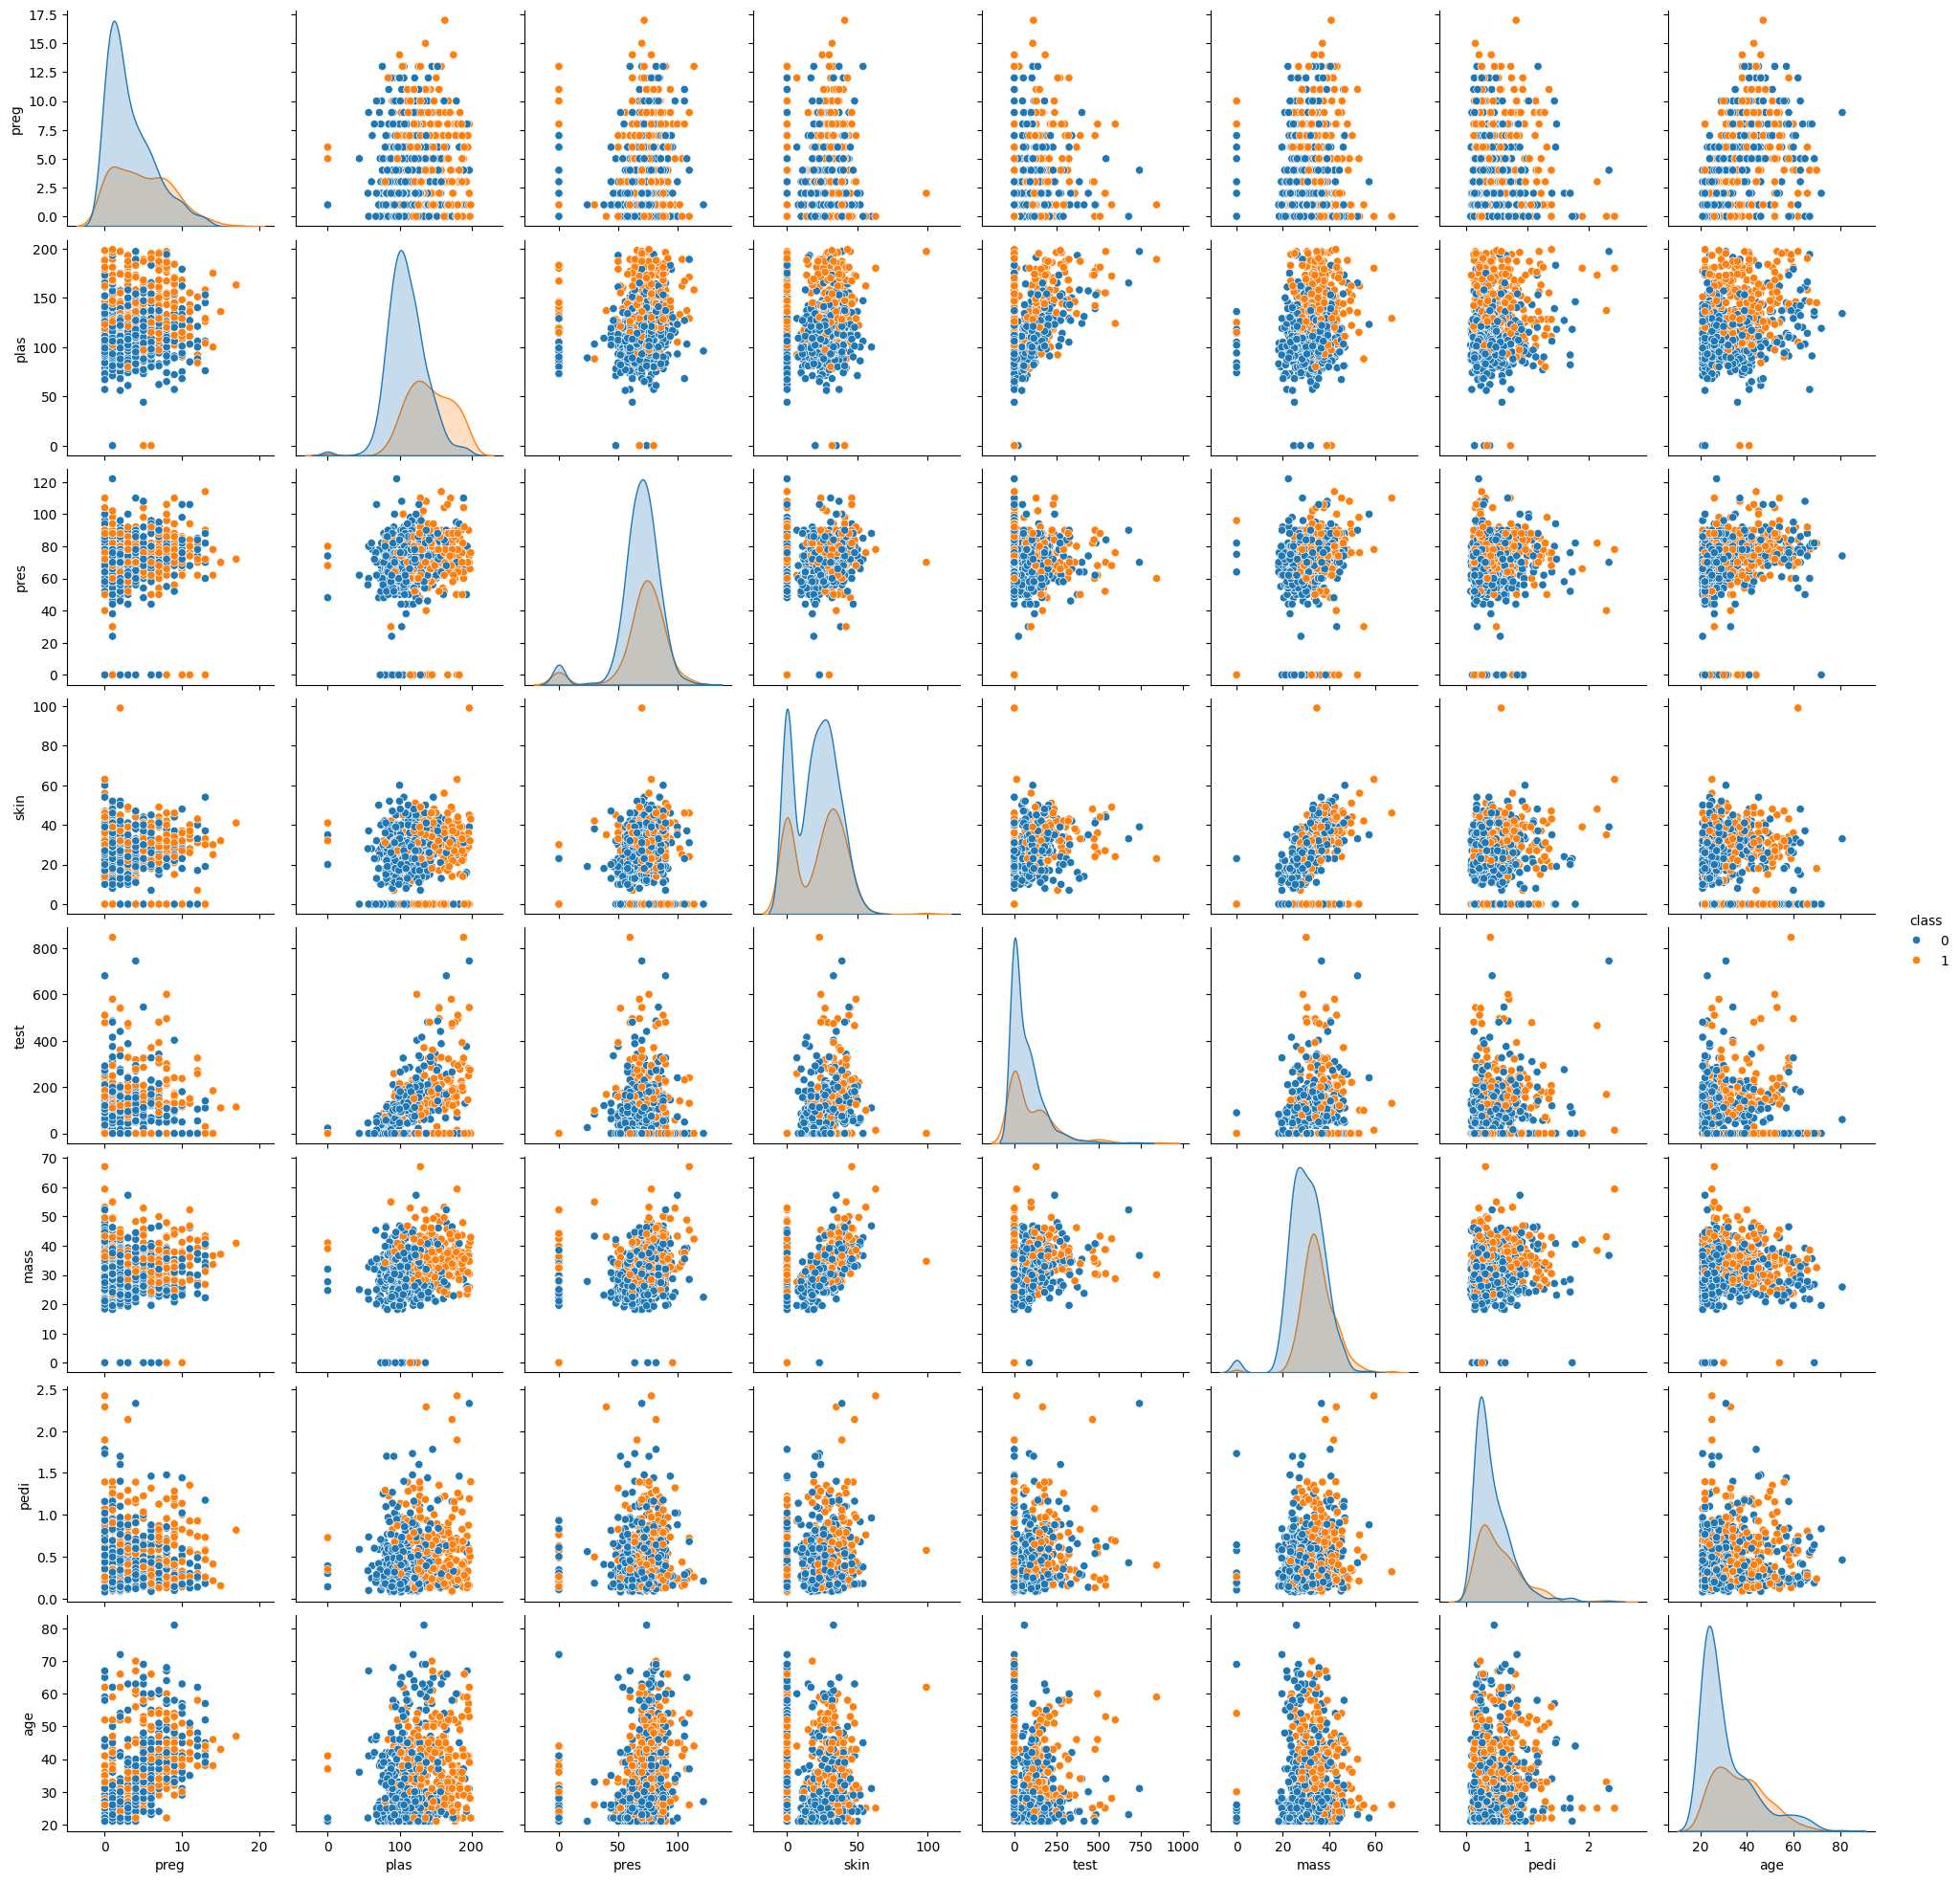

In [16]:
# haz un pairplot y usa como hue 'class'

sns.pairplot(df, hue='class')
plt.show()

<Axes: >

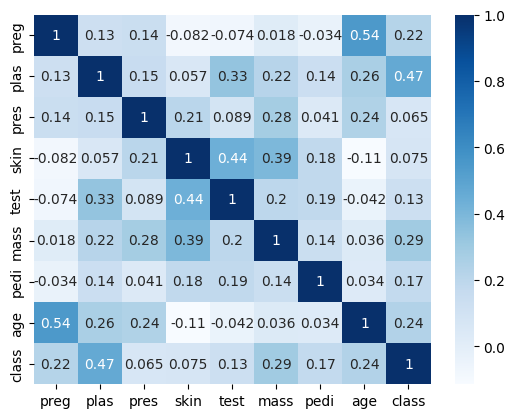

In [33]:
# haz un heatmap con la correlación, muestra los datos en las cajitas

sns.heatmap(df.corr(), annot=True, cmap='Blues')

In [39]:
# haz un value counts de la clase normalizado


df['class'].value_counts(normalize=True)


class
0    0.651042
1    0.348958
Name: proportion, dtype: float64

### 3. Bagging
Para este apartado tendrás que crear un ensemble utilizando la técnica de bagging ([BaggingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html)), mediante la cual combinarás 100 [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html). Recuerda utilizar también [cross validation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) con 10 kfolds.

**Para este apartado y siguientes, no hace falta que dividas en train/test**, por hacerlo más sencillo. Simplemente divide tus datos en features y target.

Establece una semilla

In [34]:
# define la X, la y y la semilla

X = df.drop('class', axis=1)
y = df['class']
semilla = 42

In [35]:
# importa el árbol de clasificación, un clasificador de tipo bagging y un kfold

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, KFold

In [ ]:
# haz un árbol de clasificación con profundidad 5

arbol = DecisionTreeClassifier(max_depth=5, random_state=semilla)
scores_arbol = cross_val_score(arbol, X, y, cv=5, scoring='accuracy')
print("Árbol - Media:", scores_arbol.mean())
print("Árbol - Std:", scores_arbol.std())

Árbol - Media: 0.7487819370172311
Árbol - Std: 0.035679415700201965


In [ ]:
# haz un bagging classifier con ese tipo de árbol y 100 estimadores

bagging = BaggingClassifier(estimator=arbol, n_estimators=100, random_state=semilla)
scores_bagging = cross_val_score(bagging, X, y, cv=5, scoring='accuracy')
print("Bagging - Media:", scores_bagging.mean())
print("Bagging - Std:", scores_bagging.std())

Bagging - Media: 0.7696035990153638
Bagging - Std: 0.03238157201592989


RF - Media: 0.7748068924539513


In [ ]:
# usa KFold con 10 trozos
# mira en test qué índices tienen los trozos 

# no te tiene por qué salir igual



In [40]:
# haz un crossvalscore del bagging classifier con scoring de accuracy

rf = RandomForestClassifier(n_estimators=100, max_features=3, max_depth=5, random_state=semilla)
scores_rf = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("RF - Media:", scores_rf.mean())


RF - Media: 0.7748068924539513


In [ ]:
# calcula la media y stdv del score

### 4. Random Forest
En este caso entrena un [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) con 100 árboles y un `max_features` de 3. También con validación cruzada

In [24]:
# equivalente al apartado anterior, con máxima profundidad de 5

In [ ]:
param_grid_rf = {
    'max_depth': [3, 4, 5, 6, 7],
    'max_leaf_nodes': [10, 20, 30],
    'n_estimators': [20, 50, 100]
}
rf_gs = GridSearchCV(rf, param_grid_rf, cv=KFold(n_splits=10), scoring='roc_auc', verbose=2)
rf_gs.fit(X, y)

print(rf_gs.best_estimator_)
print(rf_gs.best_params_)
print(rf_gs.best_score_)

### 5. AdaBoost
Implementa un [AdaBoostClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) con 30 árboles.

In [25]:
# equivalente al anterior con 30 estimadores

### 6. GradientBoosting
Implementa un [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) con 100 estimadores

In [26]:
# equivalente al anterior

### 7. XGBoost
Para este apartado utiliza un [XGBoostClassifier](https://docs.getml.com/latest/api/getml.predictors.XGBoostClassifier.html) con 100 estimadores. XGBoost no forma parte de la suite de modelos de sklearn, por lo que tendrás que instalarlo con pip install

In [27]:
# equivalente al anterior

### 8. Primeros resultados
Crea un dataframe con los resultados y sus algoritmos, ordenándolos de mayor a menor

### 9. Hiperparametrización
Vuelve a entrenar los modelos de nuevo, pero esta vez dividiendo el conjunto de datos en train/test y utilizando un gridsearch para encontrar los mejores hiperparámetros.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

NameError: name 'train_test_split' is not defined

In [ ]:
# RandomForestClassifier()

In [ ]:
# juega con hiperparámetros de cantidad de estimadores, max depth y max leaf nodes



450

In [ ]:
# calcula el gridsearchcv

Fitting 10 folds for each of 45 candidates, totalling 450 fits
[CV] END ....max_depth=3, max_leaf_nodes=10, n_estimators=20; total time=   0.0s
[CV] END ....max_depth=3, max_leaf_nodes=10, n_estimators=20; total time=   0.0s
[CV] END ....max_depth=3, max_leaf_nodes=10, n_estimators=20; total time=   0.0s
[CV] END ....max_depth=3, max_leaf_nodes=10, n_estimators=20; total time=   0.0s
[CV] END ....max_depth=3, max_leaf_nodes=10, n_estimators=20; total time=   0.0s
[CV] END ....max_depth=3, max_leaf_nodes=10, n_estimators=20; total time=   0.0s
[CV] END ....max_depth=3, max_leaf_nodes=10, n_estimators=20; total time=   0.0s
[CV] END ....max_depth=3, max_leaf_nodes=10, n_estimators=20; total time=   0.0s
[CV] END ....max_depth=3, max_leaf_nodes=10, n_estimators=20; total time=   0.0s
[CV] END ....max_depth=3, max_leaf_nodes=10, n_estimators=20; total time=   0.0s
[CV] END ....max_depth=3, max_leaf_nodes=10, n_estimators=50; total time=   0.0s
[CV] END ....max_depth=3, max_leaf_nodes=10, n

GridSearchCV(cv=KFold(n_splits=10, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': array([3, 4, 5, 6, 7]),
                         'max_leaf_nodes': [10, 20, 30],
                         'n_estimators': [20, 50, 100]},
             scoring='roc_auc', verbose=2)

In [ ]:
print(rf_gs.best_estimator_)
print(rf_gs.best_params_)
print(rf_gs.best_score_)

RandomForestClassifier(max_depth=np.int64(4), max_leaf_nodes=20,
                       random_state=42)
{'max_depth': np.int64(4), 'max_leaf_nodes': 20, 'n_estimators': 100}
0.8395777927787205


In [ ]:
h_rf = rf_gs.best_estimator_
h_rf.fit(X_train, y_train)

y_pred = h_rf.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(roc_auc_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7662337662337663
0.6
0.7021276595744681
0.7292929292929293
[[85 14]
 [22 33]]


In [ ]:
hrf_cv = cross_val_score(h_rf, X, y, cv=kf, scoring="accuracy")
print(hrf_cv)
print(hrf_cv.mean())
print(hrf_cv.std())

[0.7012987  0.81818182 0.71428571 0.63636364 0.75324675 0.81818182
 0.80519481 0.85714286 0.72368421 0.78947368]
0.7617053998632948
0.06424577723553478


In [ ]:
# GradientBoostingClassifier()

In [ ]:
# equivalente

450

Fitting 10 folds for each of 45 candidates, totalling 450 fits
[CV] END ....learning_rate=0.1, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ....learning_rate=0.1, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ....learning_rate=0.1, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ....learning_rate=0.1, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ....learning_rate=0.1, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ....learning_rate=0.1, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ....learning_rate=0.1, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ....learning_rate=0.1, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ....learning_rate=0.1, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ....learning_rate=0.1, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ....learning_rate=0.1, max_depth=3, n_estimators=50; total time=   0.0s
[CV] END ....learning_rate=0.1, max_depth=3, n

GridSearchCV(cv=KFold(n_splits=10, random_state=None, shuffle=False),
             estimator=GradientBoostingClassifier(random_state=42),
             param_grid={'learning_rate': [0.1, 1, 5],
                         'max_depth': array([3, 4, 5, 6, 7]),
                         'n_estimators': [20, 50, 100]},
             scoring='accuracy', verbose=2)

In [ ]:
# equivalente

GradientBoostingClassifier(max_depth=np.int64(3), random_state=42)
{'learning_rate': 0.1, 'max_depth': np.int64(3), 'n_estimators': 100}
0.7833157059756741


In [ ]:
# falta código

print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(roc_auc_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7402597402597403
0.6727272727272727
0.6271186440677966
0.7252525252525254
[[77 22]
 [18 37]]


In [ ]:
# falta código
print(hgb_cv)
print(hgb_cv.mean())
print(hgb_cv.std())

[0.71428571 0.83116883 0.74025974 0.63636364 0.79220779 0.79220779
 0.80519481 0.83116883 0.72368421 0.78947368]
0.7656015037593986
0.058212068854189405


### 10. Conclusiones finales

Escogemos el modelo que mejor generalice, es decir, el que tenga mejor métrica ante test (RF hiperparametrizado)

In [ ]:
import pickle

In [ ]:
with open("modelo_final.pkl", "wb") as f:
    # falta código

In [ ]:
with open("modelo_final.pkl", "rb") as f:
    modelo_importado = pickle.load(f)

In [ ]:
modelo_importado

RandomForestClassifier(max_depth=np.int64(4), max_leaf_nodes=20,
                       random_state=42)

In [ ]:
modelo_importado.predict([[10,10,10,10,10,10,10,10]])

c:\Users\Alberto Romero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
modelo_importado.feature_importances_

array([0.06320461, 0.38327513, 0.04084055, 0.03675811, 0.06470324,
       0.17254605, 0.06996251, 0.1687098 ])